In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

In [41]:
def time_axis(fs, duration):
    T = 1/fs
    return np.arange(0, duration, T)
def generate_sine(f, t, a = 1, p = 0):
    return a*np.sin(2*np.pi*f*t + p)
def spectrum(x, fs, NFFT = -1):
    if NFFT == -1:
        NFFT = len(x)
    X = np.fft.fft(x, NFFT)
    N = len(X)
    X = X[:N//2 + 1]
    amp = np.abs(X)*2/N
    amp[0] = amp[0]/2
    amp[-1] = amp[-1]/2
    freq = np.arange(len(amp)) * fs/N
    return freq, amp


[25 46]


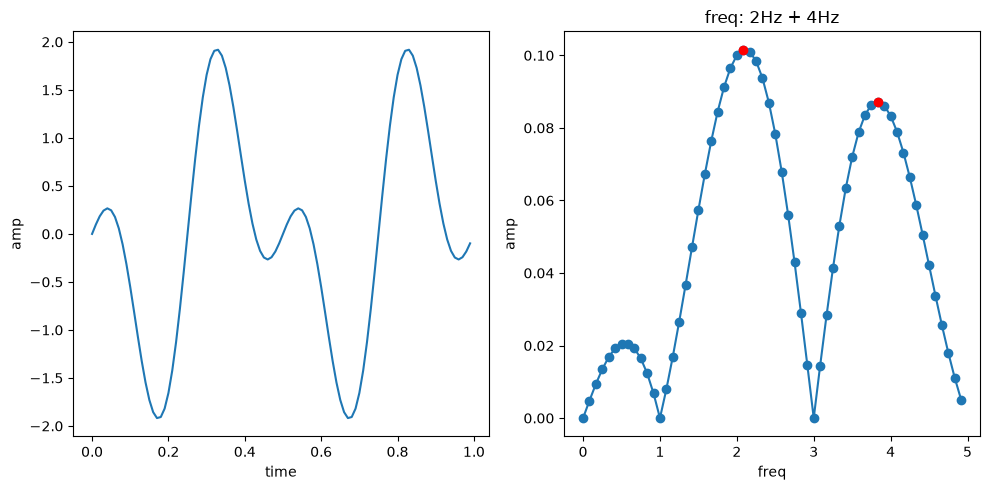

In [40]:
fs = 100
duration = 1
t = time_axis(fs, duration)
x = generate_sine(2, t, 1.2, np.pi) + generate_sine(4, t, 1, 0)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x)
plt.xlabel("time")
plt.ylabel("amp")

freq, amp = spectrum(x, fs, 12*len(x))
plt.subplot(1, 2, 2)
plt.plot(freq[:60], amp[:60], '-o')
plt.title("freq: 2Hz + 4Hz")
plt.xlabel("freq")
plt.ylabel("amp")

peaks, properties = find_peaks(amp, height=0.08, prominence=0.05, distance=5)
peak_frequencies = freq[peaks]
peak_amplitudes = amp[peaks]

plt.plot(peak_frequencies, peak_amplitudes, 'or')
print(peaks)

plt.tight_layout()

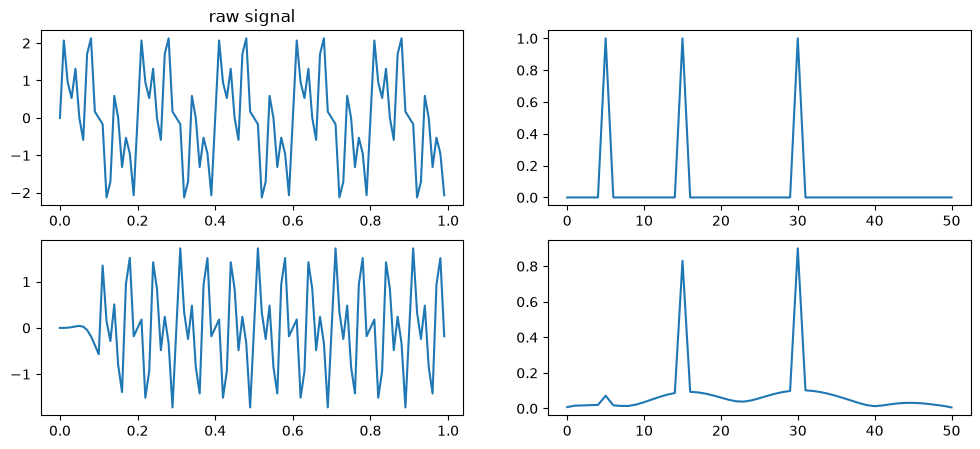

In [74]:
# apply fir
fs = 100
duration = 1
t = time_axis(fs, duration)
x = generate_sine(5, t) + generate_sine(15, t) + generate_sine(30, t)
freq, amp = spectrum(x, fs)

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
plt.plot(t, x)
plt.title("raw signal")

plt.subplot(2, 2, 2)
plt.plot(freq, amp)
# the more b , the more z that make a signal at a specific frequency to be zero
b = signal.firwin(numtaps = 21, cutoff = 10, fs = fs, pass_zero = "highpass")
a = [1.0]
y = signal.lfilter(b, a, x)
plt.subplot(2, 2, 3)
plt.plot(t, y)

freq, amp = spectrum(y, fs)
plt.subplot(2, 2, 4)
plt.plot(freq, amp)
